In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs("../reports/figures", exist_ok=True)

def save(name):
    plt.savefig(f"../reports/figures/{name}.png", dpi=300, bbox_inches="tight")

df = pd.read_parquet("../data/processed/cleaned.parquet")
print(df.shape)

(452464, 30)


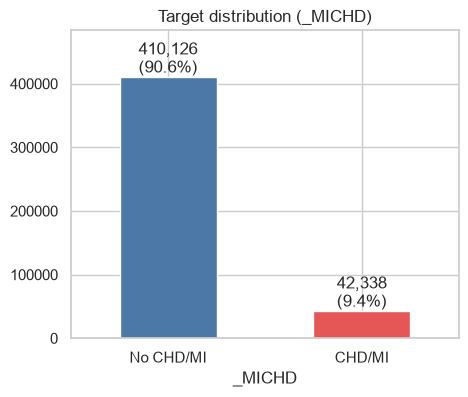

In [8]:
counts = df["_MICHD"].value_counts().sort_index()
ax = counts.plot(kind="bar", color=["#4C78A8", "#E45756"], figsize=(5, 4))
ax.set_xticklabels(["No CHD/MI", "CHD/MI"], rotation=0)
for i, v in enumerate(counts):
    ax.text(i, v, f"{v:,}\n({v/len(df):.1%})", ha="center", va="bottom")
ax.set_ylim(0, counts.max() * 1.18)
ax.set_title("Target distribution (_MICHD)")
save("01_target_balance")
plt.show()

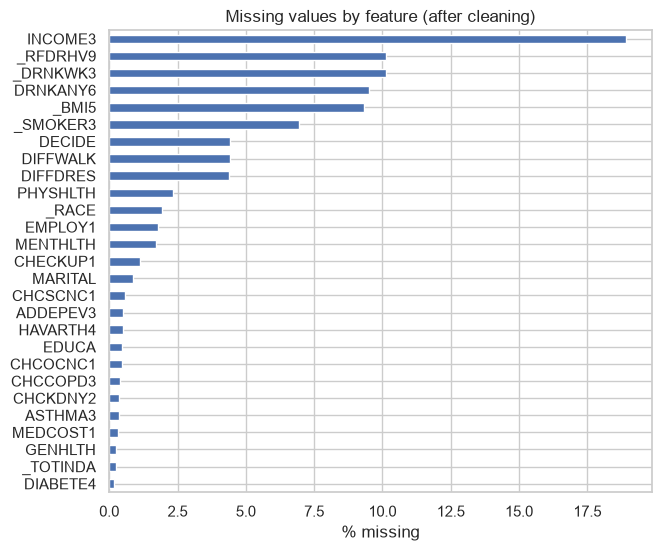

In [9]:
miss = (df.drop(columns="_MICHD").isna().mean() * 100).sort_values()
miss = miss[miss > 0]
ax = miss.plot(kind="barh", figsize=(7, 6))
ax.set_xlabel("% missing")
ax.set_title("Missing values by feature (after cleaning)")
save("02_missingness")
plt.show()

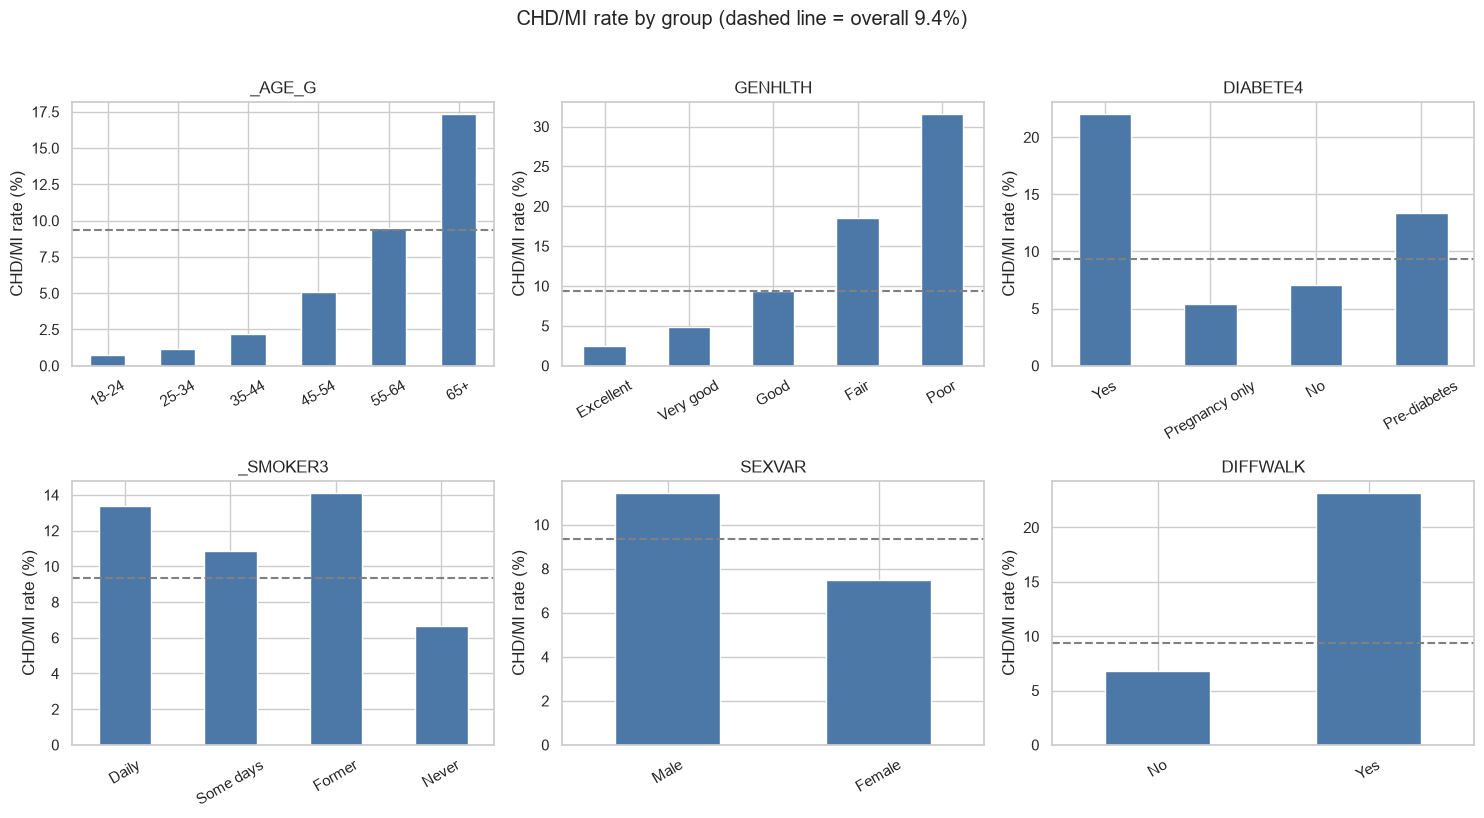

In [10]:
labels = {
    "_AGE_G":   {1: "18-24", 2: "25-34", 3: "35-44", 4: "45-54", 5: "55-64", 6: "65+"},
    "GENHLTH":  {1: "Excellent", 2: "Very good", 3: "Good", 4: "Fair", 5: "Poor"},
    "DIABETE4": {1: "Yes", 2: "Pregnancy only", 3: "No", 4: "Pre-diabetes"},
    "_SMOKER3": {1: "Daily", 2: "Some days", 3: "Former", 4: "Never"},
    "SEXVAR":   {1: "Male", 2: "Female"},
    "DIFFWALK": {0: "No", 1: "Yes"},
}
overall = df["_MICHD"].mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, m) in zip(axes.ravel(), labels.items()):
    rate = df.groupby(col)["_MICHD"].mean() * 100
    rate.index = [m.get(i, i) for i in rate.index]
    rate.plot(kind="bar", ax=ax, color="#4C78A8")
    ax.axhline(overall, ls="--", color="grey")
    ax.set_title(col)
    ax.set_ylabel("CHD/MI rate (%)")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle(f"CHD/MI rate by group (dashed line = overall {overall:.1f}%)", y=1.02)
plt.tight_layout()
save("03_rate_by_category")
plt.show()

C:\Users\Bhumika Yeggina\AppData\Local\Temp\ipykernel_8876\3113030129.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No CHD/MI", "CHD/MI"])
C:\Users\Bhumika Yeggina\AppData\Local\Temp\ipykernel_8876\3113030129.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No CHD/MI", "CHD/MI"])
C:\Users\Bhumika Yeggina\AppData\Local\Temp\ipykernel_8876\3113030129.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No CHD/MI", "CHD/MI"])
C:\Users\Bhumika Yeggina\AppData\Local\Temp\ipykernel_8876\3113030129.py:5: UserWarning: set_ticklabels() should only be used with a fixed num

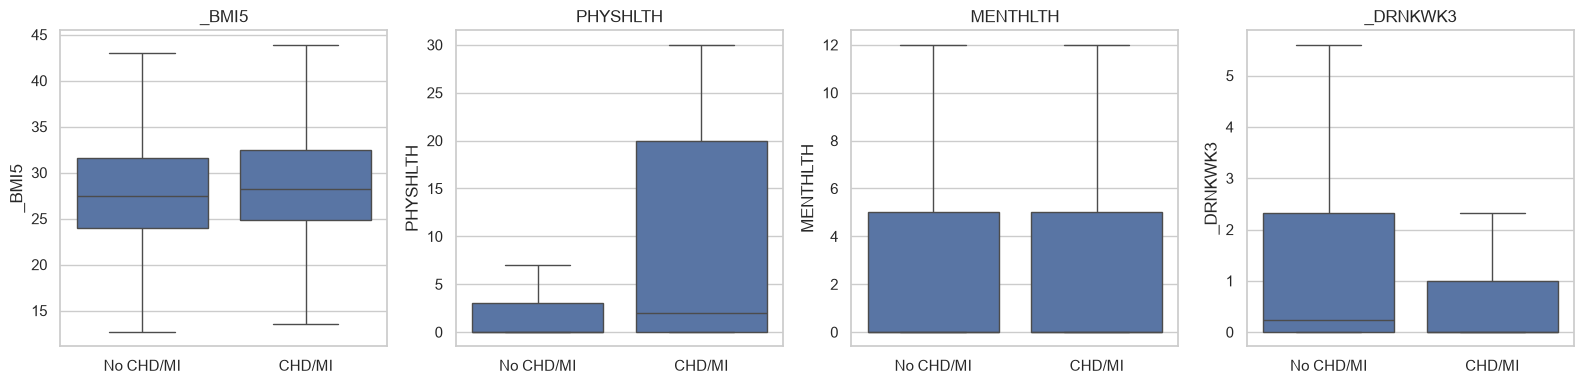

        _BMI5  PHYSHLTH  MENTHLTH  _DRNKWK3
_MICHD                                     
0       28.47      4.07      4.31      2.85
1       29.29      9.41      5.24      2.29


In [11]:
nums = ["_BMI5", "PHYSHLTH", "MENTHLTH", "_DRNKWK3"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, nums):
    sns.boxplot(data=df, x="_MICHD", y=col, ax=ax, showfliers=False)
    ax.set_xticklabels(["No CHD/MI", "CHD/MI"])
    ax.set_xlabel("")
    ax.set_title(col)
plt.tight_layout()
save("04_numeric_by_target")
plt.show()

print(df.groupby("_MICHD")[nums].mean().round(2))

GENHLTH     0.241
_AGE_G      0.232
EMPLOY1     0.230
DIFFWALK    0.206
CHCCOPD3    0.183
DIABETE4    0.181
HAVARTH4    0.177
CHCKDNY2    0.158
PHYSHLTH    0.146
MARITAL     0.140
INCOME3     0.121
_SMOKER3    0.119
dtype: float64


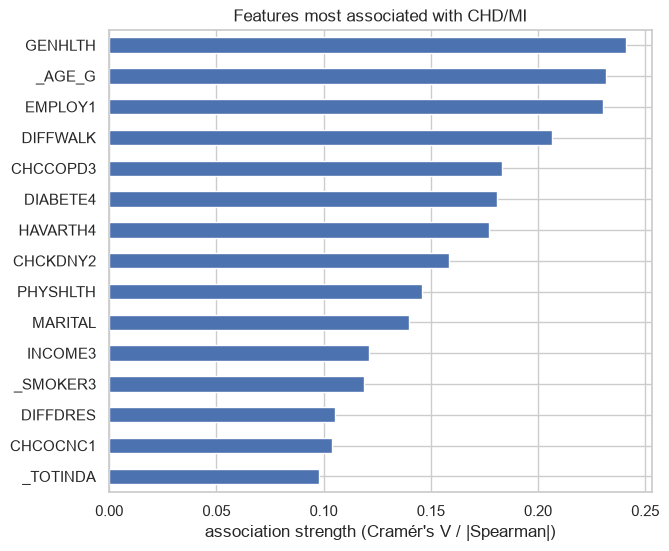

In [12]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    chi2 = chi2_contingency(t, correction=False)[0]
    return np.sqrt(chi2 / (t.values.sum() * (min(t.shape) - 1)))

cats = [c for c in df.columns if c not in nums + ["_MICHD"]]
assoc = {c: cramers_v(df[c], df["_MICHD"]) for c in cats}
for c in nums:
    assoc[c] = abs(df[[c, "_MICHD"]].corr(method="spearman").iloc[0, 1])

assoc = pd.Series(assoc).sort_values(ascending=False)
print(assoc.round(3).head(12))

assoc.head(15).sort_values().plot(kind="barh", figsize=(7, 6))
plt.xlabel("association strength (Cramér's V / |Spearman|)")
plt.title("Features most associated with CHD/MI")
save("05_top_associations")
plt.show()

## EDA findings

**1. Class balance.** Of 452,464 usable respondents, 42,338 (9.4%) report coronary heart disease or a heart attack, roughly 1 in 11. A model that always predicts "no disease" would reach about 90.6% accuracy while detecting nobody, so accuracy is misleading here. Recall, specificity, PR-AUC and explicit imbalance handling are needed.

**2. Missing data.** Missingness is low for most features. The exception is `INCOME3` at 18.9%, mostly "don't know/refused" responses. The three alcohol variables (`_RFDRHV9`, `_DRNKWK3`, `DRNKANY6`) are each missing for about 10%, largely the same respondents. Imputation will be done inside the training pipeline, with a missing-indicator for `INCOME3`, so test data never influences it.

**3. Age.** CHD/MI prevalence rises steeply with age, from under 1% at ages 18–24 to about 17% at 65+. Age is the strongest single demographic signal and will confound many other features.

**4. Self-rated general health.** The gradient is steep and monotonic: about 2–3% for "Excellent", about 9% for "Good", and over 30% for "Poor". `GENHLTH` has the highest association with the target (Cramér's V = 0.241).

**5. Diabetes and mobility.** Respondents with diabetes show about 22% prevalence against about 7% without, and pre-diabetes sits in between (about 13%). Difficulty walking more than triples the rate (about 23% vs 7%). The "pregnancy only" diabetes group is very small and shouldn't be interpreted.

**6. Smoking and sex.** Never-smokers have the lowest prevalence (about 6.5%). Current and former smokers are at roughly 11–14%, and former smokers are the highest, which is plausibly because they are older on average (an age confound, not evidence that quitting is harmful). Men have a higher rate than women (about 11.5% vs 7.5%).

**7. Numeric features.** The CHD/MI group reports more days of poor physical health (mean 9.4 vs 4.1) and a slightly higher BMI (29.3 vs 28.5). Poor mental-health days differ little (5.2 vs 4.3), and the medians are identical. Weekly alcohol intake is lower in the CHD/MI group (2.3 vs 2.9 drinks), but this should not be read as protective: people with heart disease are often advised to cut back or stop drinking, and they are older on average.

**8. Strongest associations.** The top features by association with the target are `GENHLTH` (0.241), `_AGE_G` (0.232), `EMPLOY1` (0.230), `DIFFWALK` (0.206), `CHCCOPD3` (0.183), `DIABETE4` (0.181), `HAVARTH4` (0.177) and `CHCKDNY2` (0.158). `EMPLOY1` is probably acting as a proxy for age (retired respondents), and many top features (general health, mobility, chronic conditions) overlap with one another. No single feature exceeds 0.25, so prediction will need a multivariate model rather than one dominant factor.

**Caveats.** All variables are self-reported, the target is self-reported "ever told" status, and these are associations, not causal effects. Age confounds several of the patterns above.